In [1]:
import os
import copy
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from transformers import ViTForImageClassification

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report, precision_score, recall_score)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"Seed set: {SEED}.")

Seed set: 42.


In [3]:
class SkinDataset(Dataset): 
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_name = row["image_name"]
        label = row["target"]
        
        img_path = os.path.join(self.img_dir, img_name + ".jpg")
        img = Image.open(img_path).convert("RGB")
        
        if self.transform:
            img = self.transform(img)
            
        return img, torch.tensor(label, dtype=torch.float32)

In [4]:
train_transform = T.Compose([
    T.RandomResizedCrop(
        size=224, 
        scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(
        brightness=0.1, 
        contrast=0.1, 
        saturation=0.1, 
        hue=0.05),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], 
         std=[0.229, 0.224, 0.225])])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
         std=[0.229, 0.224, 0.225])])

In [5]:
training_dataset = SkinDataset(
    csv_file="data/train/train_metadata.csv",
    img_dir="data/train/images",
    transform=train_transform)

test_dataset = SkinDataset(
    csv_file="data/test/test_metadata.csv",
    img_dir="data/test/images",
    transform=test_transform)

targets = training_dataset.df["target"].values
train_idx, valid_idx = train_test_split(
    np.arange(len(training_dataset)),
    test_size=0.15,
    stratify=targets,
    random_state=SEED)

In [6]:
train_dataset = torch.utils.data.Subset(training_dataset, train_idx)
valid_dataset = copy.deepcopy(training_dataset)
valid_dataset = torch.utils.data.Subset(valid_dataset, valid_idx)
valid_dataset.dataset.transform = test_transform

In [7]:
train_indices = train_dataset.indices
labels = training_dataset.df["target"].values[train_indices]
class_counts = np.bincount(labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False)

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device using: {DEVICE}")

Device using: cuda


In [10]:
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=1,
    ignore_mismatched_sizes=True)
vit_model.to(DEVICE);

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([1])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([1, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [11]:
vit_model.classifier = nn.Sequential(
    nn.Dropout(0.3), 
    nn.Linear(vit_model.config.hidden_size, 1)
).to(DEVICE)

In [12]:
criterion = nn.BCEWithLogitsLoss()

In [13]:
for param in vit_model.vit.parameters():
    param.requires_grad = False

for param in vit_model.classifier.parameters():
    param.requires_grad = True

In [14]:
optimizer = torch.optim.AdamW(
    vit_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4)

In [15]:
NUM_EPOCHS = 30
HEAD_EPOCHS = 5
PATIENCE = 5
best_auc = 0
early_stop_counter = 0

In [16]:
history = {
    "epoch": [],
    "train_loss": [], "train_accuracy": [],
    "train_f1": [], "train_auc": [],

    "valid_loss": [], "valid_acc": [],
    "valid_f1": [], "valid_auc": []}

In [17]:
for epoch in range(NUM_EPOCHS):
    if epoch == 0:
        print("── [Phase 1]: Training Classifier Head Only ──────────────────────────────────────────────")
        
    if epoch == HEAD_EPOCHS:
        print("\n── [PHASE 2]: Gradual Unfreezing ────────────────────────────────────────────────────────")

        # unfreeze last 4 transformer blocks
        for layer in vit_model.vit.encoder.layer[-4:]:
            for param in layer.parameters():
                param.requires_grad = True
                
        optimizer = torch.optim.AdamW(
            filter(
                lambda p: p.requires_grad,
                vit_model.parameters()),
            lr=5e-6,
            weight_decay=1e-4)
        
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2)
        
    if epoch == 10:
        print("\n[PHASE 3] Full Fine-Tuning")
        
        for param in vit_model.vit.parameters():
            param.requires_grad = True
        
        optimizer = torch.optim.AdamW(vit_model.parameters(), lr=3e-6, weight_decay=1e-4)
        
    # train
    vit_model.train()
    total_train_loss = 0
    train_preds, train_probs, train_targets = [], [], []
    
    train_tqdm = tqdm(train_loader, desc=f"[TRAINING] [{epoch+1}/{NUM_EPOCHS}]")
    
    for images, labels in train_tqdm:
        images = images.to(DEVICE)
        labels = labels.float().to(DEVICE).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = vit_model(images).logits
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
        # predictions
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()
        train_preds.extend(preds.detach().cpu().numpy())
        train_probs.extend(probs.detach().cpu().numpy())
        train_targets.extend(labels.detach().cpu().numpy())
        train_tqdm.set_postfix({"train_loss": f"{loss.item():.4f}"})
        
    # train metrics
    avg_train_loss = total_train_loss / len(train_loader)
    train_preds = np.array(train_preds).flatten()
    train_probs = np.array(train_probs).flatten()
    train_targets = np.array(train_targets).flatten()
    
    train_acc = accuracy_score(train_targets, train_preds)
    train_f1 = f1_score(train_targets, train_preds)
    train_auc = roc_auc_score(train_targets, train_probs)
    
    # validation
    vit_model.eval()
    total_valid_loss = 0
    valid_preds, valid_probs, valid_targets = [], [], []
    
    valid_tqdm = tqdm(valid_loader, desc=f"[VALIDATING] [{epoch+1}/{NUM_EPOCHS}]")
    with torch.no_grad():
        for images, labels in valid_tqdm:
            images = images.to(DEVICE)
            labels = labels.float().to(DEVICE).unsqueeze(1)
            
            outputs1 = vit_model(images).logits
            flipped = torch.flip(images, dims=[3])
            outputs2 = vit_model(flipped).logits
            outputs = (outputs1 + outputs2) / 2
            
            loss = criterion(outputs, labels)
            total_valid_loss += loss.item()
            
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            
            valid_preds.extend(preds.cpu().numpy())
            valid_probs.extend(probs.cpu().numpy())
            valid_targets.extend(labels.cpu().numpy())
            valid_tqdm.set_postfix({"valid_loss": f"{loss.item():.4f}"})
            
    # validation metrics
    avg_valid_loss = total_valid_loss / len(valid_loader)
    valid_preds = np.array(valid_preds).flatten()
    valid_probs = np.array(valid_probs).flatten()
    valid_targets = np.array(valid_targets).flatten()
    
    valid_acc = accuracy_score(valid_targets, valid_preds)
    valid_f1 = f1_score(valid_targets, valid_preds)
    valid_auc = roc_auc_score(valid_targets, valid_probs)
    
    if epoch >= HEAD_EPOCHS:
        scheduler.step(valid_auc)
    
    # result
    print(f"- train_loss: {avg_train_loss:.4f} - train_acc: {train_acc:.4f} - train_f1: {train_f1:.4f} - train_auc: {train_auc:.4f}")
    print(f"- valid_loss: {avg_valid_loss:.4f} - valid_acc: {valid_acc:.4f} - valid_f1: {valid_f1:.4f} - valid_auc: {valid_auc:.4f}")
    
    # history
    history["epoch"].append(epoch+1)
    history["train_loss"].append(avg_train_loss)
    history["train_accuracy"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_auc"].append(train_auc)
    history["valid_loss"].append(avg_valid_loss)
    history["valid_acc"].append(valid_acc)
    history["valid_f1"].append(valid_f1)
    history["valid_auc"].append(valid_auc)

    # save best model
    if valid_auc > best_auc:
        best_auc = valid_auc
        torch.save(vit_model.state_dict(), "vit_model.pth")
        print("\t[!] Best model saved.")
    else:
        early_stop_counter += 1
        print(f"\t[!] No Improvement. Early stop counter: {early_stop_counter}/{PATIENCE}")
        
    if early_stop_counter >= PATIENCE:
        print(f"\t[EARLY STOPPING] Triggered. Best Validation AUC: {best_auc:.4f}")
        break

── [Phase 1]: Training Classifier Head Only ──────────────────────────────────────────────


[VALIDATING] [1/30]: 100%|██████████| 22/22 [00:49<00:00,  2.26s/it, valid_loss=0.5215]


- train_loss: 0.5616 - train_acc: 0.7068 - train_f1: 0.7034 - train_auc: 0.7796
- valid_loss: 0.4475 - valid_acc: 0.7947 - valid_f1: 0.5882 - valid_auc: 0.8601
	[!] Best model saved.


[VALIDATING] [2/30]: 100%|██████████| 22/22 [00:49<00:00,  2.26s/it, valid_loss=0.4961]


- train_loss: 0.4941 - train_acc: 0.7675 - train_f1: 0.7819 - train_auc: 0.8371
- valid_loss: 0.4828 - valid_acc: 0.7713 - valid_f1: 0.5761 - valid_auc: 0.8606
	[!] Best model saved.


...

- train_loss: 0.3656 - train_acc: 0.8386 - train_f1: 0.8449 - train_auc: 0.9150
- valid_loss: 0.4114 - valid_acc: 0.8035 - valid_f1: 0.6127 - valid_auc: 0.8933
	[!] No Improvement. Early stop counter: 3/5


[VALIDATING] [13/30]: 100%|██████████| 22/22 [01:23<00:00,  3.79s/it, valid_loss=0.5166]


- train_loss: 0.3098 - train_acc: 0.8729 - train_f1: 0.8790 - train_auc: 0.9424
- valid_loss: 0.4040 - valid_acc: 0.8123 - valid_f1: 0.6322 - valid_auc: 0.8971
	[!] No Improvement. Early stop counter: 4/5


[VALIDATING] [14/30]: 100%|██████████| 22/22 [01:20<00:00,  3.66s/it, valid_loss=0.5945]

- train_loss: 0.2880 - train_acc: 0.8853 - train_f1: 0.8854 - train_auc: 0.9510
- valid_loss: 0.3837 - valid_acc: 0.8211 - valid_f1: 0.6347 - valid_auc: 0.8967
	[!] No Improvement. Early stop counter: 5/5
	[EARLY STOPPING] Triggered. Best Validation AUC: 0.8985


In [18]:
valid_probs_list, valid_targets_list = [], []
vit_model.eval()
with torch.no_grad():
    for images, labels in tqdm(valid_loader):
        images = images.to(DEVICE)
        probs = torch.sigmoid(vit_model(images).logits).cpu().numpy()
        valid_probs_list.extend(probs)
        valid_targets_list.extend(labels.numpy())
        
best_f1 = 0
optimal_threshold = 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    preds = (np.array(valid_probs_list) > thresh).astype(int)
    current_f1 = f1_score(np.array(valid_targets_list), preds)
    if current_f1 > best_f1:
        best_f1 = current_f1
        optimal_threshold = thresh
        
print(f"[!] Tuned Optimal Threshold for F1: {optimal_threshold:.4f} (valid_f1: {best_f1:.4f})")

100%|██████████| 22/22 [00:47<00:00,  2.14s/it]

[!] Tuned Optimal Threshold for F1: 0.4300 (valid_f1: 0.6441)


In [19]:
final_probs, final_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="[TESTING WITH TTA]"):
        images = images.to(DEVICE)
        
        p1 = torch.sigmoid(vit_model(images).logits)
        p2 = torch.sigmoid(vit_model(torch.flip(images, dims=[3])).logits)
        p3 = torch.sigmoid(vit_model(torch.flip(images, dims=[2])).logits)
        p4 = torch.sigmoid(vit_model(torch.rot90(images, 1, [2, 3])).logits)
        
        mean_prob = (p1 + p2 + p3 + p4) / 4.0
        
        final_probs.extend(mean_prob.cpu().numpy())
        final_targets.extend(labels.numpy())

final_probs = np.array(final_probs).flatten()
final_targets = np.array(final_targets).flatten()

[TESTING WITH TTA]: 100%|██████████| 48/48 [02:29<00:00,  3.11s/it]


In [20]:
final_probs = np.array(final_probs).flatten()
final_targets = np.array(final_targets).flatten()
final_preds = (final_probs > optimal_threshold).astype(int)

In [21]:
final_acc = accuracy_score(final_targets, final_preds)
final_f1 = f1_score(final_targets, final_preds)
final_auc = roc_auc_score(final_targets, final_probs)
final_precision = precision_score(final_targets, final_preds)
final_recall = recall_score(final_targets, final_preds)

print(f"- Accuracy: {final_acc:.4f}")
print(f"- F1 Score: {final_f1:.4f}")
print(f"- AUC ROC: {final_auc:.4f}")
print(f"- Precision: {final_precision:.4f}")
print(f"- Recall: {final_recall:.4f}")

- Accuracy: 0.8058
- F1 Score: 0.6260
- AUC ROC: 0.8885
- Precision: 0.4980
- Recall: 0.8425


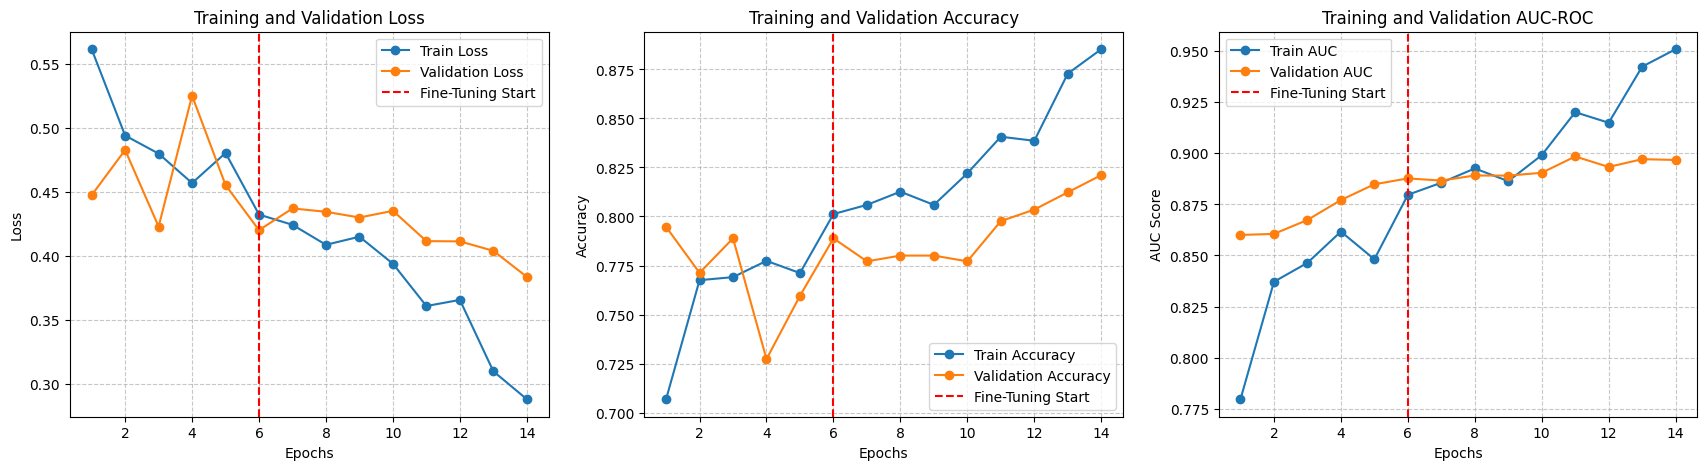

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 5))

ax1.plot(
    history['epoch'], 
    history['train_loss'], 
    label='Train Loss', 
    marker='o')
ax1.plot(
    history['epoch'], 
    history['valid_loss'], 
    label='Validation Loss', 
    marker='o')
ax1.axvline(
    x=HEAD_EPOCHS+1,
    color='red',
    linestyle='--',
    label='Fine-Tuning Start')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

ax2.plot(
    history['epoch'], 
    history['train_accuracy'], 
    label='Train Accuracy', 
    marker='o')
ax2.plot(
    history['epoch'], 
    history['valid_acc'], 
    label='Validation Accuracy', 
    marker='o')
ax2.axvline(
    x=HEAD_EPOCHS+1,
    color='red',
    linestyle='--',
    label='Fine-Tuning Start')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

ax3.plot(
    history['epoch'], 
    history['train_auc'], 
    label='Train AUC', 
    marker='o')
ax3.plot(
    history['epoch'], 
    history['valid_auc'], 
    label='Validation AUC', 
    marker='o')
ax3.axvline(
    x=HEAD_EPOCHS+1,
    color='red',
    linestyle='--',
    label='Fine-Tuning Start')
ax3.set_title('Training and Validation AUC-ROC')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('AUC Score')
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend()

plt.show()

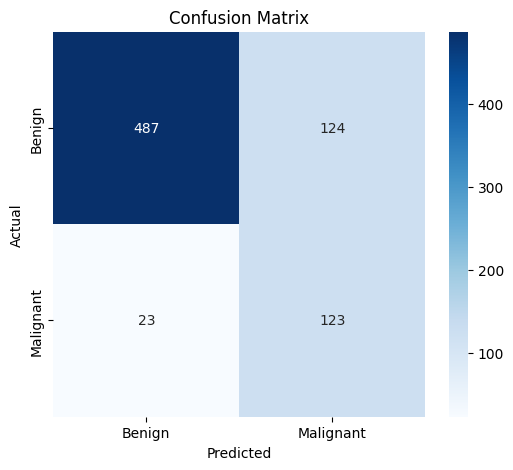

In [23]:
cm = confusion_matrix(final_targets, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
print(classification_report(final_targets, final_preds, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.95      0.80      0.87       611
   Malignant       0.50      0.84      0.63       146

    accuracy                           0.81       757
   macro avg       0.73      0.82      0.75       757
weighted avg       0.87      0.81      0.82       757

